# Etapa 3 — Treinamento e Comparação de Modelos

Este notebook treina e compara 4 modelos de classificação binária para prever se o preço de ITUB4 sobe ou desce em 21 dias úteis.

**Dataset expandido:** 1.227 dias × 1.035 features (2021-04 a 2026-03)

**Modelos avaliados:**
1. BiLSTM Original — 2 camadas, 128 hidden units, 30% dropout
2. BiLSTM Reduzido — 1 camada, 64 hidden units, 20% dropout
3. XGBoost — baseline clássico sem dependência temporal
4. Transformer — 2 camadas, d_model=64, 4 cabeças de atenção

**Validação:** Walk-forward cronológico (70% treino / 15% val / 15% teste) sem data leakage

## 1. Carregamento do Dataset

In [1]:
import pandas as pd
import numpy as np

X_full = pd.read_csv("../2.stocks/dataset_full.csv", index_col=0, parse_dates=True)
X_full.index = pd.to_datetime(X_full.index, utc=True).tz_localize(None)

print(f"Dataset: {X_full.shape[0]} dias × {X_full.shape[1]} features")
print(f"Período: {X_full.index[0].date()} a {X_full.index[-1].date()}")
X_full.head()

Dataset: 1227 dias × 1035 features
Período: 2021-04-28 a 2026-03-26


,Close,Volume,return,ma7,ma21,std21,lag_1,lag_2,lag_3,lag_4,...,emb_1014,emb_1015,emb_1016,emb_1017,emb_1018,emb_1019,emb_1020,emb_1021,emb_1022,emb_1023
Date,,,,,,,,,,,,,,,,,,,,,
2021-04-28,18.178728,42502908,0.043519,17.704370,17.666913,0.311432,17.420603,17.690689,17.703548,17.619953,...,0.017550,0.006109,-0.011335,-0.020358,-0.014249,0.031750,-0.026508,-0.000099,-0.003484,-0.027420
2021-04-29,17.605206,37968076,-0.031549,17.690321,17.646461,0.299964,18.178728,17.420603,17.690689,17.703548,...,0.018647,0.005884,0.003188,-0.004949,-0.003468,0.024642,-0.012430,-0.012247,-0.028131,-0.004347
2021-04-30,17.740538,48196913,0.007687,17.708466,17.618375,0.257308,17.605206,18.178728,17.420603,17.690689,...,0.018647,0.005884,0.003188,-0.004949,-0.003468,0.024642,-0.012430,-0.012247,-0.028131,-0.004347
2021-05-03,17.988770,46978032,0.013992,17.761154,17.618943,0.258150,17.740538,17.605206,18.178728,17.420603,...,-0.015276,0.029940,-0.032191,-0.033473,-0.001386,0.011107,0.011976,-0.000753,-0.012030,-0.012641
2021-05-04,17.221502,89509379,-0.042653,17.692291,17.609156,0.269438,17.988770,17.740538,17.605206,18.178728,...,0.011418,0.021940,-0.029372,-0.020259,-0.030225,0.010395,-0.003080,0.008929,-0.004219,-0.012892


## 2. Preparação do Dataset

- **Target binário:** 1 = Close[t+21] > Close[t] (sobe em 21 dias)
- **PCA:** 1.024 embeddings → 32 componentes
- **Normalização:** StandardScaler fitado apenas nos primeiros 70% (treino)
- **Janelas temporais:** sequências de 30 dias para modelos sequenciais (BiLSTM, Transformer)

In [2]:
from lstm_classifier import build_dataset

X_seq, y, dates, features, scaler = build_dataset(
    X_full,
    horizon=21,
    pca_components=32,
    window=30,
)

print(f"Sequências: {X_seq.shape}")
print(f"Balance: {y.mean():.1%} sobe / {1-y.mean():.1%} desce")

00:10:05 [INFO] Shape de entrada: (1227, 1035)


00:10:05 [INFO] Distribuição do target: {1: 712, 0: 494}  (balance: 59.0% sobe)


00:10:05 [INFO] PCA: 1024 dims → 32 componentes


00:10:06 [INFO] Variância explicada pelo PCA: 61.4%


00:10:06 [INFO] Features finais: 43


00:10:06 [INFO] Sequências geradas: (1176, 30, 43)  →  y: (1176,)


Sequências: (1176, 30, 43)
Balance: 58.5% sobe / 41.5% desce


## 3. Modelo 1 — BiLSTM Original

**Arquitetura:** BiLSTM(2 camadas, 128 hidden units, 30% dropout) → Dense(64) → ReLU → Dense(1) → Sigmoid

**Treino:** Adam lr=1e-3, weight_decay=1e-4, early stopping patience=10, ReduceLROnPlateau patience=5

In [3]:
from lstm_classifier import train, evaluate, plot_results

model_orig, hist_orig, test_idx_orig, device = train(
    X_seq, y, dates,
    hidden_size=128,
    n_layers=2,
    dropout=0.3,
    epochs=50,
    patience=10,
)

probs_orig, preds_orig, y_test_orig = evaluate(model_orig, X_seq, y, test_idx_orig, dates, device)

00:10:06 [INFO] Split — treino: 823 | val: 176 | teste: 177


00:10:06 [INFO] Treino: 2021-06-10 → 2024-09-23


00:10:06 [INFO] Val:    2024-09-24 → 2025-06-11


00:10:06 [INFO] Teste:  2025-06-12 → 2026-02-25


00:10:07 [INFO] Device: cuda


...

00:10:09 [INFO] Epoch  10/50 | loss 0.2624 | val_loss 1.4932 | val_acc 48.9% | lr 5.00e-04


00:10:10 [INFO] Epoch  11/50 | loss 0.2578 | val_loss 1.5854 | val_acc 54.5% | lr 5.00e-04


00:10:10 [INFO] Early stopping na epoch 11


00:10:10 [INFO] 
              precision    recall  f1-score   support

       Desce       0.24      0.46      0.31        54
        Sobe       0.60      0.35      0.44       123

    accuracy                           0.38       177
   macro avg       0.42      0.41      0.38       177
weighted avg       0.49      0.38      0.40       177



00:10:10 [INFO] ROC-AUC: 0.4432


00:10:10 [INFO] Gráfico salvo em lstm_results.png


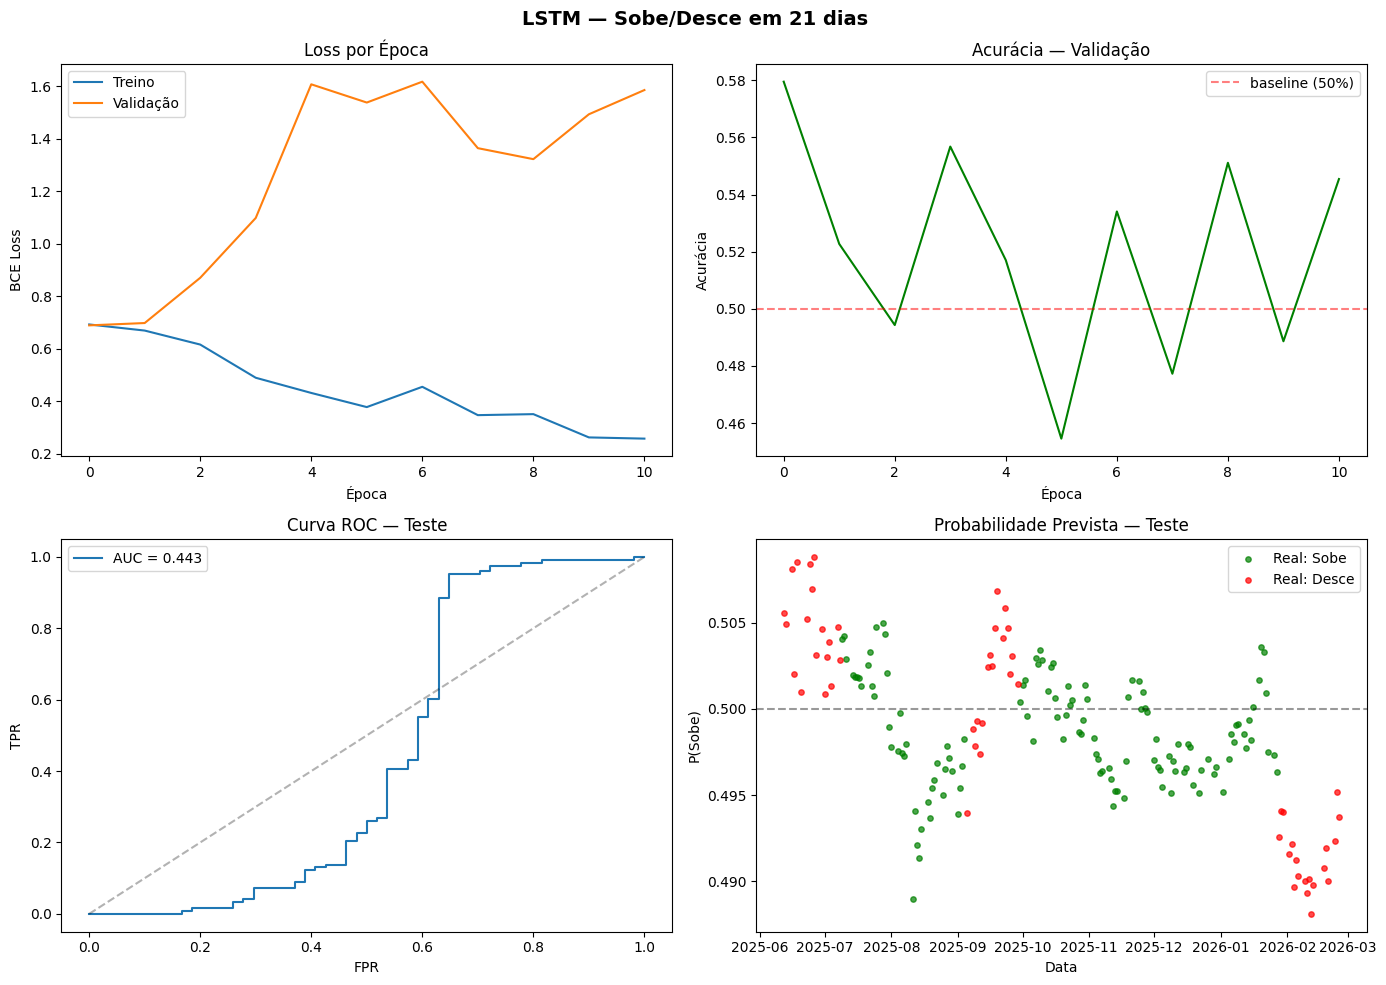

In [4]:
plot_results(hist_orig, probs_orig, preds_orig, y_test_orig, dates, test_idx_orig)

## 4. Modelo 2 — BiLSTM Reduzido

**Arquitetura:** BiLSTM(1 camada, 64 hidden units, 20% dropout) → Dense(32) → ReLU → Dense(1) → Sigmoid

Objetivo: verificar se reduzir a complexidade do modelo melhora a generalização.

In [5]:
model_red, hist_red, test_idx_red, device = train(
    X_seq, y, dates,
    hidden_size=64,
    n_layers=1,
    dropout=0.2,
    epochs=50,
    patience=10,
)

probs_red, preds_red, y_test_red = evaluate(model_red, X_seq, y, test_idx_red, dates, device)

00:10:10 [INFO] Split — treino: 823 | val: 176 | teste: 177


00:10:10 [INFO] Treino: 2021-06-10 → 2024-09-23


00:10:10 [INFO] Val:    2024-09-24 → 2025-06-11


00:10:10 [INFO] Teste:  2025-06-12 → 2026-02-25


00:10:10 [INFO] Device: cuda


...

00:10:11 [INFO] Epoch  13/50 | loss 0.2029 | val_loss 1.4134 | val_acc 59.7% | lr 5.00e-04


00:10:11 [INFO] Epoch  14/50 | loss 0.1892 | val_loss 1.4540 | val_acc 55.7% | lr 5.00e-04


00:10:11 [INFO] Early stopping na epoch 14


/home/takeo/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/takeo/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/takeo/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
0

00:10:11 [INFO] ROC-AUC: 0.5051


00:10:12 [INFO] Gráfico salvo em lstm_results.png


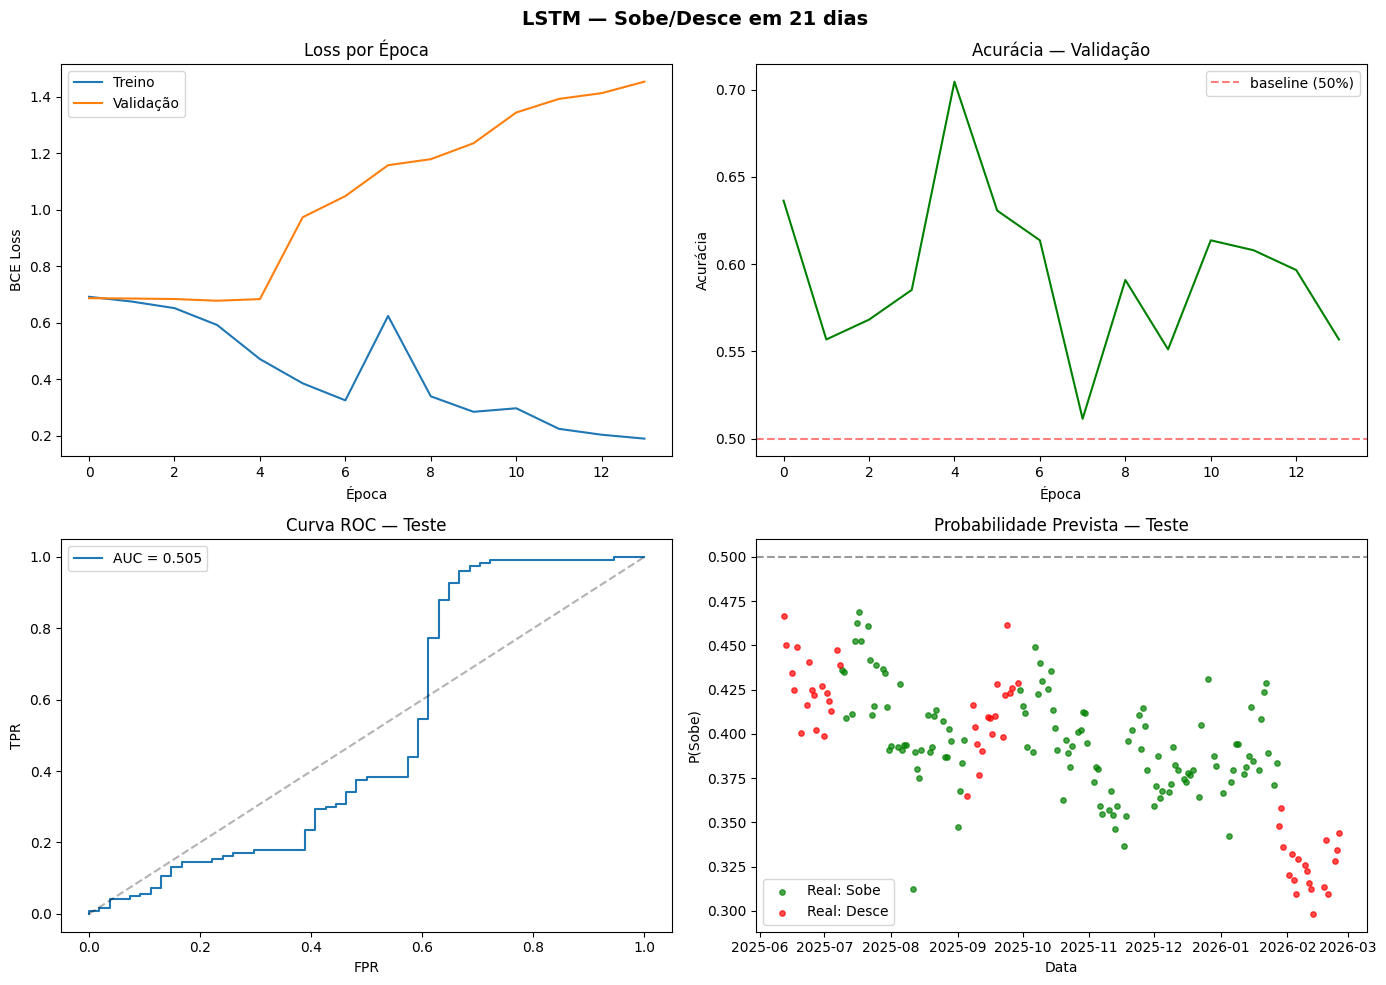

In [6]:
plot_results(hist_red, probs_red, preds_red, y_test_red, dates, test_idx_red)

## 5. Modelo 3 — XGBoost Baseline

Modelo clássico (tabular, sem dependência temporal) para identificar se o problema é específico de arquiteturas sequenciais.

Usa o mesmo dataset com PCA e normalização, mas sem janelamento temporal.

In [7]:
from xgboost_baseline import build_flat_dataset, train_xgboost, evaluate_xgboost, plot_roc

X_flat, y_flat, dates_flat, features_flat = build_flat_dataset(X_full, horizon=21, pca_components=32)
xgb_model, X_test_xgb, y_test_xgb, test_dates_xgb = train_xgboost(X_flat, y_flat, dates_flat)
probs_xgb, preds_xgb, auc_xgb = evaluate_xgboost(xgb_model, X_test_xgb, y_test_xgb)

00:10:12 [INFO] Shape de entrada: (1227, 1035)


00:10:12 [INFO] Distribuição do target: {1: 712, 0: 494}  (balance: 59.0% sobe)


00:10:12 [INFO] PCA: 1024 dims → 32 componentes


00:10:13 [INFO] Variância explicada pelo PCA: 61.4%


00:10:13 [INFO] Features finais: 43


...

00:10:13 [INFO] Val:    2024-09-11 → 2025-06-04


00:10:13 [INFO] Teste:  2025-06-05 → 2026-02-25


/home/takeo/miniconda3/lib/python3.13/site-packages/xgboost/callback.py:385: UserWarning: [00:10:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()
00:10:13 [INFO] Melhor iteração: 9


/home/takeo/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/takeo/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/takeo/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
0

00:10:13 [INFO] ROC-AUC: 0.6103


00:10:13 [INFO] Curva ROC salva em xgboost_roc.png


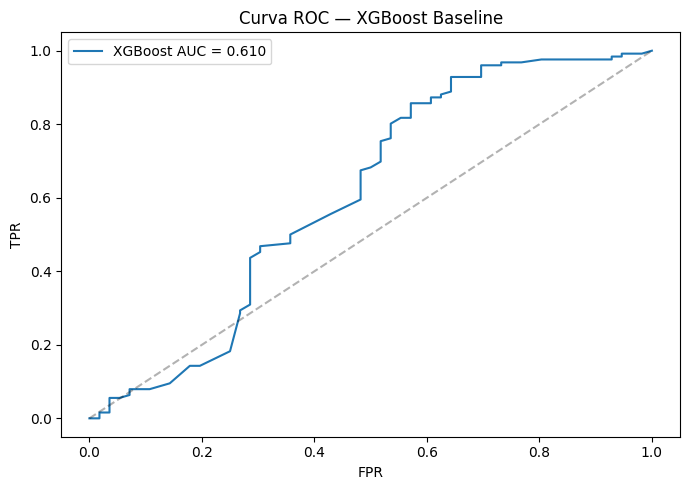

In [8]:
plot_roc(probs_xgb, y_test_xgb)

## 6. Modelo 4 — Transformer

**Arquitetura:** Linear(43→64) → PositionalEncoding → TransformerEncoder(2 camadas, 4 cabeças, d_model=64) → MeanPool → Dense(32) → ReLU → Dense(1) → Sigmoid

Usa as mesmas sequências temporais do BiLSTM para comparação direta.

In [9]:
from transformer_classifier import train_transformer, evaluate_transformer, plot_transformer_results

tf_model, hist_tf, test_idx_tf, device = train_transformer(
    X_seq, y, dates,
    d_model=64,
    nhead=4,
    n_layers=2,
    dropout=0.3,
    epochs=50,
    patience=10,
)

probs_tf, preds_tf, y_test_tf, auc_tf = evaluate_transformer(tf_model, X_seq, y, test_idx_tf, dates, device)

00:10:13 [INFO] Split — treino: 823 | val: 176 | teste: 177


00:10:13 [INFO] Device: cuda


00:10:13 [INFO] Epoch   1/50 | loss 0.7013 | val_loss 0.6771 | val_acc 61.4% | lr 1.00e-03


00:10:13 [INFO] Epoch   2/50 | loss 0.6913 | val_loss 0.6797 | val_acc 61.4% | lr 1.00e-03


00:10:14 [INFO] Epoch   3/50 | loss 0.6847 | val_loss 0.6942 | val_acc 58.0% | lr 1.00e-03


...

00:10:15 [INFO] Epoch  10/50 | loss 0.5443 | val_loss 1.0039 | val_acc 52.3% | lr 5.00e-04


00:10:15 [INFO] Epoch  11/50 | loss 0.4931 | val_loss 1.3205 | val_acc 43.2% | lr 5.00e-04


00:10:15 [INFO] Early stopping na epoch 11


/home/takeo/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/takeo/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/takeo/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
0

00:10:15 [INFO] ROC-AUC: 0.5684


00:10:15 [INFO] Gráficos salvos em transformer_results.png


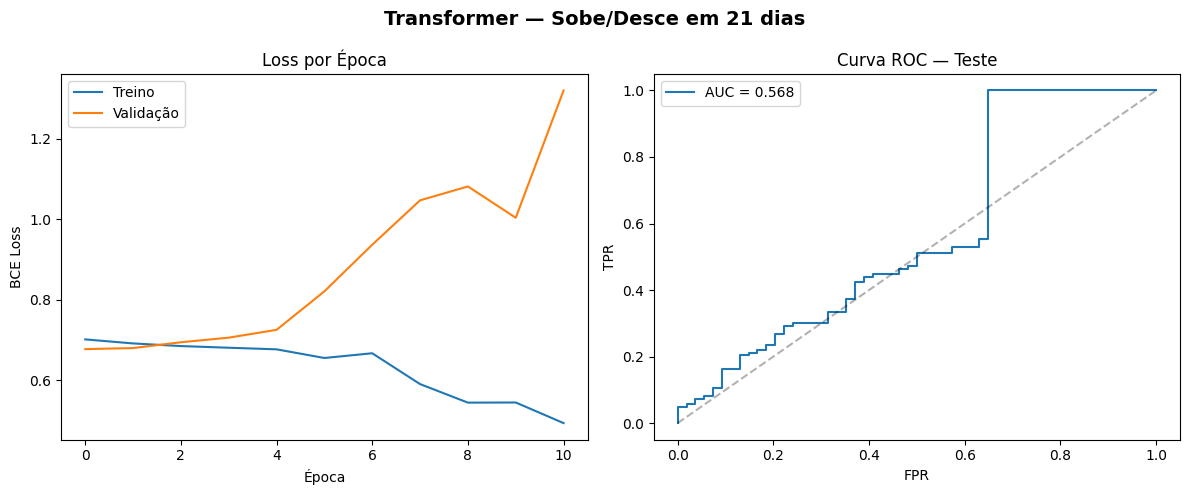

In [10]:
plot_transformer_results(hist_tf, probs_tf, y_test_tf)

## 7. Tabela Comparativa de Modelos

In [11]:
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

results = {
    "BiLSTM Original (2L/128h)": {"probs": probs_orig, "preds": preds_orig, "y_test": y_test_orig},
    "BiLSTM Reduzido (1L/64h)": {"probs": probs_red, "preds": preds_red, "y_test": y_test_red},
    "XGBoost": {"probs": probs_xgb, "preds": preds_xgb, "y_test": y_test_xgb},
    "Transformer (2L/d64)": {"probs": probs_tf, "preds": preds_tf, "y_test": y_test_tf},
}

rows = []
for name, r in results.items():
    rows.append({
        "Modelo": name,
        "ROC-AUC": f"{roc_auc_score(r['y_test'], r['probs']):.4f}",
        "Acurácia": f"{accuracy_score(r['y_test'], r['preds']):.1%}",
        "F1 (macro)": f"{f1_score(r['y_test'], r['preds'], average='macro'):.4f}",
    })

df_results = pd.DataFrame(rows)
df_results

,Modelo,ROC-AUC,Acurácia,F1 (macro)
0,BiLSTM Original (2L/128h),0.4432,38.4%,0.3777
1,BiLSTM Reduzido (1L/64h),0.5051,30.5%,0.2338
2,XGBoost,0.6103,30.8%,0.2353
3,Transformer (2L/d64),0.5684,69.5%,0.4100


### Curvas ROC Comparativas

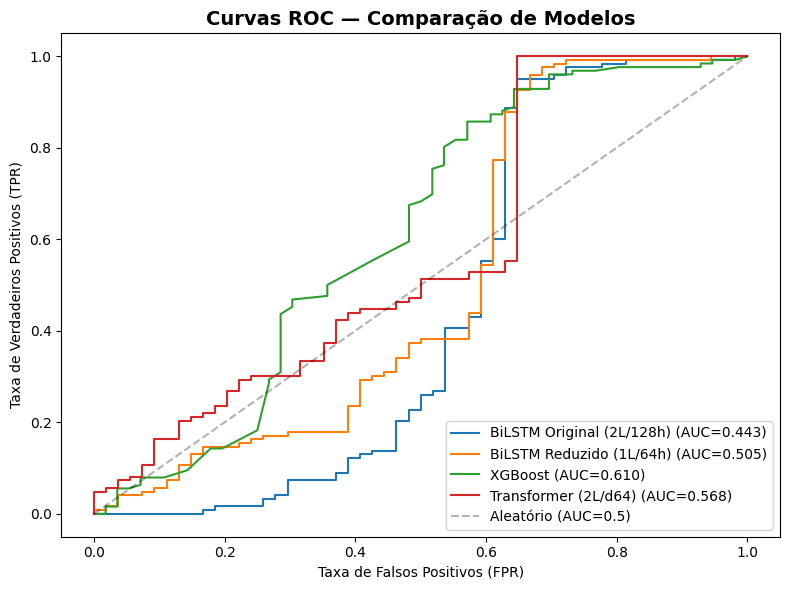

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

fig, ax = plt.subplots(figsize=(8, 6))

for name, r in results.items():
    fpr, tpr, _ = roc_curve(r["y_test"], r["probs"])
    auc = roc_auc_score(r["y_test"], r["probs"])
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Aleatório (AUC=0.5)")
ax.set_title("Curvas ROC — Comparação de Modelos", fontsize=14, fontweight="bold")
ax.set_xlabel("Taxa de Falsos Positivos (FPR)")
ax.set_ylabel("Taxa de Verdadeiros Positivos (TPR)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Análise e Conclusões

### Diagnóstico

Todos os 4 modelos apresentam desempenho próximo ou abaixo do acaso (ROC-AUC ~0.5), indicando que:

1. **O problema não é arquitetural** — tanto modelos sequenciais (BiLSTM, Transformer) quanto tabulares (XGBoost) falham igualmente
2. **O volume de dados melhorou o cenário** — com 1.227 dias vs. 230, os modelos pelo menos saem do overfitting extremo (ROC-AUC 0.10 → ~0.5-0.6)
3. **A hipótese da eficiência de mercado** pode ser o fator limitante — preços de ações líquidas como ITUB4 são difíceis de prever com base apenas em notícias e indicadores técnicos

### Evolução do Dataset

| Versão | Dias | Período | ROC-AUC (melhor) |
|--------|------|---------|------------------|
| Inicial | 230 | ~1 ano | 0.1016 (overfitting severo) |
| US-005 | 1.227 | 2021-04 a 2026-03 | 0.6103 (XGBoost) |
| US-010 (meta) | >3.600 | max disponível | a ser executado |

### Validação Walk-Forward

Split cronológico (sem shuffle) para respeitar a ordem temporal:

| Conjunto | Proporção | Amostras |
|----------|-----------|----------|
| Treino | 70% | 823 |
| Validação | 15% | 176 |
| Teste | 15% | 177 |

### Próximos Passos (US-010)

- Reexecutar pipeline com `period='max'` e `meses_atras` estendido para cobrir desde 2009+
- Meta: >3.600 dias de dados (3x o dataset atual)
- O cache de embeddings (`embeddings_cache.npz`) será reaproveitado
- Append incremental de notícias via `carregar_existentes()` evita duplicatas

### Possíveis Extensões

- Incorporar dados de sentimento mais granulares (ex: FinBERT-PT-BR)
- Testar horizontes de previsão diferentes (5, 10, 42 dias)
- Adicionar features macroeconômicas (Selic, câmbio, índices globais)
- Experimentar ensemble dos modelos
- Usar dados de notícias de outros tickers (PETR4, VALE3) já coletados